Jako dane pogodowe wybrano temepraturę średnią w °C oraz opady w mm zarejestrowane we wszystkie dni września 2023, września 2024 oraz września 2025 r. w mieście Zamość. Skorzystano z strony: https://rafalraczynski.com.pl/imgw-archiwum/

In [108]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

#Wczytanie danych do notatnika
df = pd.read_csv('pogoda_zamosc.csv', sep='\t')
temp_values = df['Temperatura średnia [°C]'].values
rain_values = df['Opady [mm]'].values

#Ustawiam k na 7 dni
k = 7
#Wersja tylko dla temepratury
X_t, y_t = [], []
#Wersja temepratura plus opady
X_to, y_to = [], []

#Tworzenie okien dla każdego z 3 analizowanych miesięcy osobno
for x in [0, 30, 60]:
    month_temp = temp_values[x : x + 30]
    month_rain = rain_values[x : x + 30]
    
    for i in range(len(month_temp) - k):
        #Tylko temperatura
        X_t.append(month_temp[i : i+k])
        y_t.append(month_temp[i+k])
        
        #Wersja temepratura plus opady
        dane_to = np.column_stack((month_temp[i : i+k], month_rain[i : i+k])).flatten()
        X_to.append(dane_to)
        y_to.append(month_temp[i+k])

#Tworzenie tensorów
X_t_t = torch.tensor(np.array(X_t), dtype=torch.float32)
y_t_t = torch.tensor(np.array(y_t), dtype=torch.float32).view(-1, 1)

X_t_to = torch.tensor(np.array(X_to), dtype=torch.float32)
y_t_to = torch.tensor(np.array(y_to), dtype=torch.float32).view(-1, 1)

#Podział na zbiory zachowując ciągłosc czasową (każdy miesiąc to 23 próbki, łącznie 69)
#Zbiór treningowy: rok 2023 (23 próbki) + pierwsza połowa 2024 (11 próbek) = 34 próbki
X_train_t, y_train_t = X_t_t[:34], y_t_t[:34]
X_train_to, y_train_to = X_t_to[:34], y_t_to[:34]

#Zbiór walidacyjny: druga połowa 2024(12 próbek)
X_val_t, y_val_t = X_t_t[34:46], y_t_t[34:46]
X_val_to, y_val_to = X_t_to[34:46], y_t_to[34:46]

#Zbiór testowy: cały wrzesień 2025 (23 próbki)
X_test_t, y_test_t = X_t_t[46:], y_t_t[46:]
X_test_to, y_test_to = X_t_to[46:], y_t_to[46:]

print(f'Wymiary tensora z temperaturą: {X_train_t.shape}')
print(f'Wymiary tensora z temperaturą i opadami: {X_train_to.shape}')

Wymiary tensora z temperaturą: torch.Size([34, 7])
Wymiary tensora z temperaturą i opadami: torch.Size([34, 14])


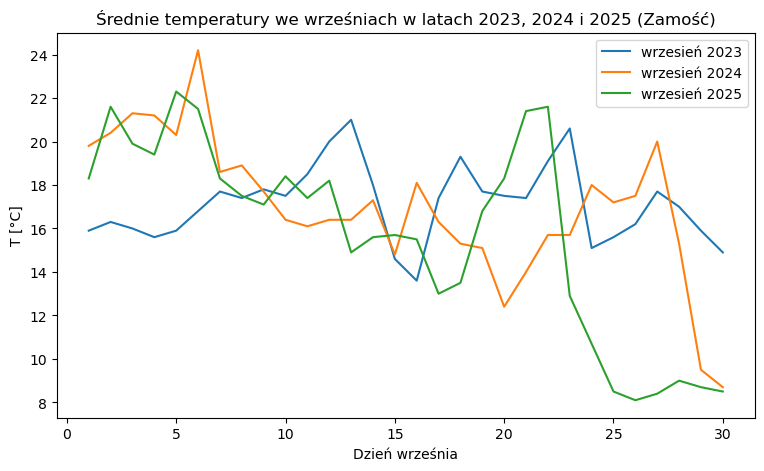

In [109]:
#Wizualizacja danych rzeczywistych
dni_miesiaca = range(1, 31)

#Temperatury dla poszczególnych lat
temp_2023 = temp_values[0:30]
temp_2024 = temp_values[30:60]
temp_2025 = temp_values[60:90]

plt.figure(figsize=(9, 5))
plt.plot(dni_miesiaca, temp_2023, label='wrzesień 2023')
plt.plot(dni_miesiaca, temp_2024, label='wrzesień 2024')
plt.plot(dni_miesiaca, temp_2025, label='wrzesień 2025')

plt.title('Średnie temperatury we wrześniach w latach 2023, 2024 i 2025 (Zamość)')
plt.xlabel('Dzień września')
plt.ylabel('T [°C]')
plt.legend()
plt.show()

In [110]:
#Model regresji liniowej zbudowanej w oparciu tylko o temperaturę
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.lin = nn.Linear(7, 1)
        
    def forward(self, x):
        return self.lin(x)

model_reg = LinearRegressionModel()

learning_rate = 0.01

loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model_reg.parameters(), lr=learning_rate)

num_epochs = 1000

train_loss_reg, val_loss_reg = [], []

for epoch in range(num_epochs):
    #Trenowanie
    model_reg.train()
    optimizer.zero_grad()
    outputs = model_reg(X_train_t)
    loss = loss_function(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    train_loss_reg.append(loss.item())
    
    #Walidacja
    model_reg.eval()
    with torch.no_grad():
        val_outputs = model_reg(X_val_t)
        val_loss = loss_function(val_outputs, y_val_t)
        val_loss_reg.append(val_loss.item())


#Błąd MSE dla ostatniej epoki
print(f'Błąd MSE ostatniej eopki - zbiór treningowy: {train_loss_reg[-1]:.4f}')
print(f'Błąd MSE ostatniej eopki - zbiór walidacyjnym:{val_loss_reg[-1]:.4f}')

Błąd MSE ostatniej eopki - zbiór treningowy: 2.4977
Błąd MSE ostatniej eopki - zbiór walidacyjnym:8.0011


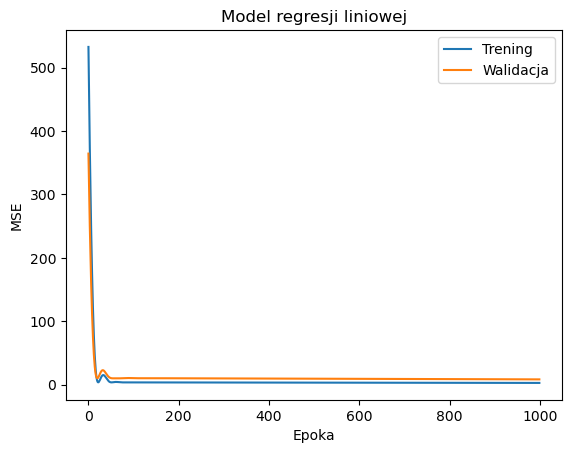

In [102]:
# Wykres krzywej uczenia regresji liniowej zbudowanej w oparciu tylko o temperaturę
plt.plot(train_loss_reg, label='Trening')
plt.plot(val_loss_reg, label = 'Walidacja')
plt.legend()
plt.xlabel('Epoka')
plt.ylabel('MSE')
plt.title('Model regresji liniowej')
plt.show()

In [90]:
#Model wykorzystujący sieci neuronowe oparty tylko na temperaturze(ReLU, Adam)
class WeatherNNModel(nn.Module):
    def __init__(self):
        super(WeatherNNModel, self).__init__()
        self.fc1 = nn.Linear(7, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model_nn = WeatherNeuralNetwork()
loss_function = nn.MSELoss()
learning_rate = 0.01
optimizer = torch.optim.Adam(model_nn.parameters(), lr=learning_rate)

num_epochs = 1000
train_loss_nn, val_loss_nn = [], []

for epoch in range(num_epochs):
    #Trenowanie
    model_nn.train()
    optimizer.zero_grad()
    outputs = model_nn(X_train_t)
    loss = loss_function(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    train_loss_nn.append(loss.item())
    
    #Walidacja
    model_nn.eval()
    with torch.no_grad():
        val_outputs = model_nn(X_val_t)
        val_loss = loss_function(val_outputs, y_val_t)
        val_loss_nn.append(val_loss.item())


#Błąd MSE dla ostatniej epoki
print(f'Błąd MSE ostatniej eopki - zbiór treningowy: {train_loss_nn[-1]:.4f}')
print(f'Błąd MSE ostatniej eopki - zbiór walidacyjnym:{val_loss_nn[-1]:.4f}')

Błąd MSE ostatniej eopki - zbiór treningowy: 1.7648
Błąd MSE ostatniej eopki - zbiór walidacyjnym:7.2580


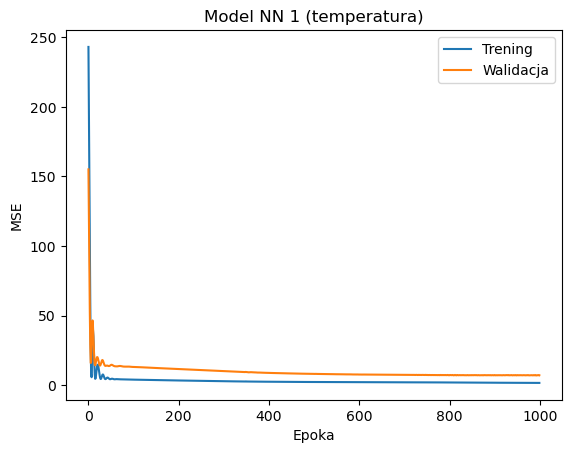

In [103]:
# Wykres krzywej uczenia modelu wykorzystującego sieci neuronowe opartego tylko na temperaturze
plt.plot(train_loss_nn, label='Trening')
plt.plot(val_loss_nn, label = 'Walidacja')
plt.legend()
plt.xlabel('Epoka')
plt.ylabel('MSE')
plt.title('Model NN 1 (temperatura)')
plt.show()

In [91]:
#Model wykorzystujący sieci neuronowe oparty tylko na temperaturze z innymi parametrami (LeakyReLU, L2, SGD)

class WeatherNNModel_2(nn.Module):
    def __init__(self):
        super(WeatherNNModel_2, self).__init__()
        self.fc1 = nn.Linear(7, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)
        
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        return self.fc3(x)

model_nn_2 = WeatherNNModel_2()
loss_function = nn.MSELoss()

#Obniżyłam learning_rate do 0.0005
learning_rate = 0.0005
#Dodanie regularyzacji L2: weight_decay = 1e-4
optimizer_2 = torch.optim.SGD(model_nn_2.parameters(), lr=learning_rate, weight_decay=1e-4)

num_epochs_2 = 1000 
train_loss_nn_2, val_loss_nn_2 = [], []

for epoch in range(num_epochs_2):
    #Trenowanie
    model_nn_2.train()
    optimizer_2.zero_grad()
    outputs = model_nn_2(X_train_t)
    loss = loss_function(outputs, y_train_t)
    loss.backward()
    optimizer_2.step()
    train_loss_nn_2.append(loss.item())
    
    #Walidacja
    model_nn_2.eval()
    with torch.no_grad():
        val_outputs = model_nn_2(X_val_t)
        val_loss = loss_function(val_outputs, y_val_t)
        val_loss_nn_2.append(val_loss.item())


#Błąd MSE dla ostatniej epoki
print(f'Błąd MSE ostatniej eopki - zbiór treningowy: {train_loss_nn_2[-1]:.4f}')
print(f'Błąd MSE ostatniej eopki - zbiór walidacyjnym:{val_loss_nn_2[-1]:.4f}')

Błąd MSE ostatniej eopki - zbiór treningowy: 3.3324
Błąd MSE ostatniej eopki - zbiór walidacyjnym:8.1921


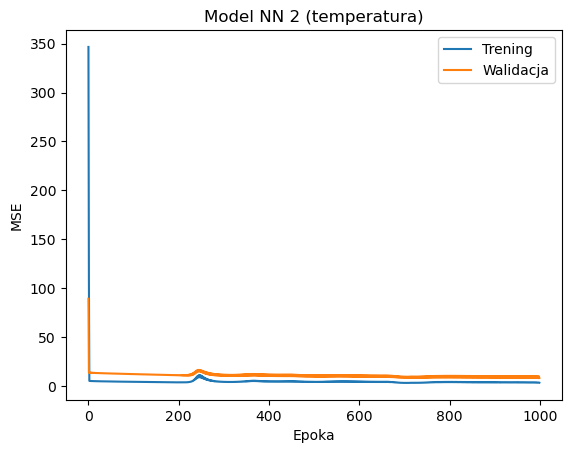

In [104]:
# Wykres krzywej uczenia wersji drugiej modelu wykorzystującego sieci neuronowe opartego tylko na temperaturze
plt.plot(train_loss_nn_2, label='Trening')
plt.plot(val_loss_nn_2, label = 'Walidacja')
plt.legend()
plt.xlabel('Epoka')
plt.ylabel('MSE')
plt.title('Model NN 2 (temperatura)')
plt.show()

In [92]:
#Model wykorzystujący sieci neuronowe oparty tylko na temperaturze
#Analogiczny jak powyżej ale z wykorzystaniem Adam a nie SGD (dodatkowo zastosowanie LeakyReLU oraz L2)

class WeatherNNModel_3(nn.Module):
    def __init__(self):
        super(WeatherNNModel_3, self).__init__()
        self.fc1 = nn.Linear(7, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)
        
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        return self.fc3(x)

model_nn_3 = WeatherNNModel_3()
loss_function = nn.MSELoss()

#Zastosowałam inny learning_rate do 0.005
learning_rate = 0.005
#Dodanie regularyzacji L2: weight_decay = 1e-4
optimizer_3 = torch.optim.Adam(model_nn_3.parameters(), lr=learning_rate, weight_decay=1e-4)

num_epochs_3 = 1000 
train_loss_nn_3, val_loss_nn_3 = [], []

for epoch in range(num_epochs_3):
    #Trenowanie
    model_nn_3.train()
    optimizer_3.zero_grad()
    outputs = model_nn_3(X_train_t)
    loss = loss_function(outputs, y_train_t)
    loss.backward()
    optimizer_3.step()
    train_loss_nn_3.append(loss.item())
    
    #Walidacja
    model_nn_3.eval()
    with torch.no_grad():
        val_outputs = model_nn_3(X_val_t)
        val_loss = loss_function(val_outputs, y_val_t)
        val_loss_nn_3.append(val_loss.item())


#Błąd MSE dla ostatniej epoki
print(f'Błąd MSE ostatniej eopki - zbiór treningowy: {train_loss_nn_3[-1]:.4f}')
print(f'Błąd MSE ostatniej eopki - zbiór walidacyjnym:{val_loss_nn_3[-1]:.4f}')

Błąd MSE ostatniej eopki - zbiór treningowy: 1.7591
Błąd MSE ostatniej eopki - zbiór walidacyjnym:9.0222


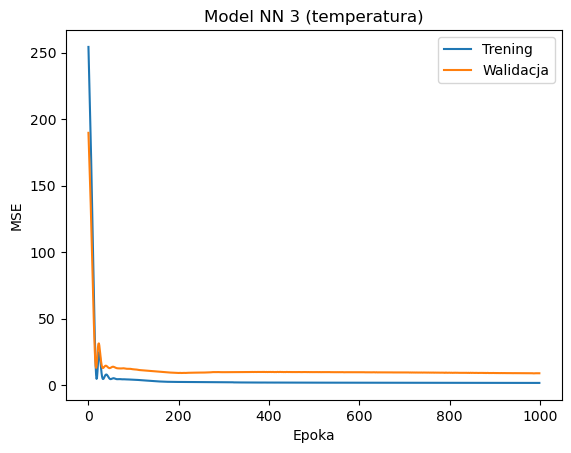

In [105]:
# Wykres krzywej uczenia wersji trzeciej modelu wykorzystującego sieci neuronowe opartego tylko na temperaturze
plt.plot(train_loss_nn_3, label='Trening')
plt.plot(val_loss_nn_3, label = 'Walidacja')
plt.legend()
plt.xlabel('Epoka')
plt.ylabel('MSE')
plt.title('Model NN 3 (temperatura)')
plt.show()

In [93]:
#Model wykorzystujący sieci neuronowe oparty na temperaturze i na opadach
class WeatherNN_TemOpa(nn.Module):
    def __init__(self):
        super(WeatherNN_TemOpa, self).__init__()
        self.fc1 = nn.Linear(14, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model_TemOpa = WeatherNN_TemOpa()
loss_function = nn.MSELoss()
learning_rate = 0.005
optimizer = torch.optim.Adam(model_TemOpa.parameters(), lr=learning_rate)

epochs = 1000
train_loss_TemOpa, val_loss_TemOpa = [], []

for epoch in range(epochs):
    #Trenowanie
    model_TemOpa.train()
    optimizer.zero_grad()
    outputs = model_TemOpa(X_train_to)
    loss = loss_function(outputs, y_train_to)
    loss.backward()
    optimizer.step()
    train_loss_TemOpa.append(loss.item())
    
    #Walidacja
    model_TemOpa.eval()
    with torch.no_grad():
        val_outputs = model_TemOpa(X_val_to)
        val_loss = loss_function(val_outputs, y_val_to)
        val_loss_TemOpa.append(val_loss.item())


#Błąd MSE dla ostatniej epoki
print(f'Błąd MSE ostatniej eopki - zbiór treningowy: {train_loss_TemOpa[-1]:.4f}')
print(f'Błąd MSE ostatniej eopki - zbiór walidacyjnym:{val_loss_TemOpa[-1]:.4f}')

Błąd MSE ostatniej eopki - zbiór treningowy: 0.5031
Błąd MSE ostatniej eopki - zbiór walidacyjnym:22.4490


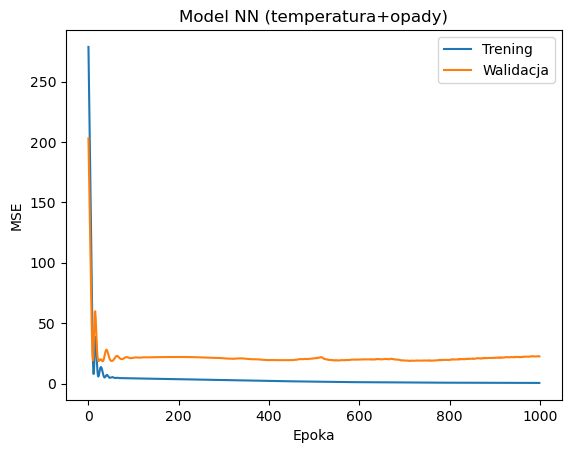

In [106]:
# Wykres krzywej uczenia modelu wykorzystującego sieci neuronowe opartego na temperaturze i na opadach
plt.plot(train_loss_TemOpa, label='Trening')
plt.plot(val_loss_TemOpa, label = 'Walidacja')
plt.legend()
plt.xlabel('Epoka')
plt.ylabel('MSE')
plt.title('Model NN (temperatura+opady)')
plt.show()

In [111]:
#Przetestowanie modeli na zbiorze testowym (wrzesień 2025)
# Ustawiamy modele w tryb ewaluacji
model_reg.eval()
model_nn.eval()
model_nn_2.eval()
model_nn_3.eval() 
model_TemOpa.eval()

with torch.no_grad():
    #Predykcje dla września 2025
    pred_reg = model_reg(X_test_t)
    pred_nn = model_nn(X_test_t)
    pred_nn_2 = model_nn_2(X_test_t)
    pred_nn_3 = model_nn_3(X_test_t)
    pred_TemOpa = model_TemOpa(X_test_to)
    
    #Wyliczenie MAE
    mae_reg = F.l1_loss(pred_reg, y_test_t).item()
    mae_nn = F.l1_loss(pred_nn, y_test_t).item()
    mae_nn_2 = F.l1_loss(pred_nn_2, y_test_t).item()
    mae_nn_3 = F.l1_loss(pred_nn_3, y_test_t).item()
    mae_TemOpa = F.l1_loss(pred_TemOpa, y_test_to).item()

    # Wyliczenie MSE
    mse_reg = F.mse_loss(pred_reg, y_test_t).item()
    mse_nn = F.mse_loss(pred_nn, y_test_t).item()
    mse_nn_2 = F.mse_loss(pred_nn_2, y_test_t).item()
    mse_nn_3 = F.mse_loss(pred_nn_3, y_test_t).item()
    mse_TemOpa = F.mse_loss(pred_TemOpa, y_test_to).item()

print("MAE przewidywania temperatury na zbiorze testowym:")
print(f'Model regresji liniowej: {mae_reg:.2f} °C')
print(f'Model 1 sieci neuronowej opartej tylko na temperaturze: {mae_nn:.2f} °C')
print(f'Model 2 sieci neuronowej opartej tylko na temperaturze: {mae_nn_2:.2f} °C')
print(f'Model 3 sieci neuronowej opartej tylko na temperaturze: {mae_nn_3:.2f} °C')
print(f'Model sieci neuronowej opartej na temperaturze i opadach: {mae_TemOpa:.2f} °C')

print("Błąd MSE na zbiorze testowym dla każdego modelu:")
print(f'Model regresji liniowej: {mse_reg:.2f}')
print(f'Model 1 sieci neuronowej opartej tylko na temperaturze: {mse_nn:.2f}')
print(f'Model 2 sieci neuronowej opartej tylko na temperaturze: {mse_nn_2:.2f}')
print(f'Model 3 sieci neuronowej opartej tylko na temperaturze: {mse_nn_3:.2f}')
print(f'Model sieci neuronowej opartej na temperaturze i opadach: {mse_TemOpa:.2f}')

MAE przewidywania temperatury na zbiorze testowym:
Model regresji liniowej: 1.98 °C
Model 1 sieci neuronowej opartej tylko na temperaturze: 2.22 °C
Model 2 sieci neuronowej opartej tylko na temperaturze: 2.05 °C
Model 3 sieci neuronowej opartej tylko na temperaturze: 2.42 °C
Model sieci neuronowej opartej na temperaturze i opadach: 4.70 °C
Błąd MSE na zbiorze testowym dla każdego modelu:
Model regresji liniowej: 7.31
Model 1 sieci neuronowej opartej tylko na temperaturze: 9.40
Model 2 sieci neuronowej opartej tylko na temperaturze: 7.32
Model 3 sieci neuronowej opartej tylko na temperaturze: 10.66
Model sieci neuronowej opartej na temperaturze i opadach: 39.43


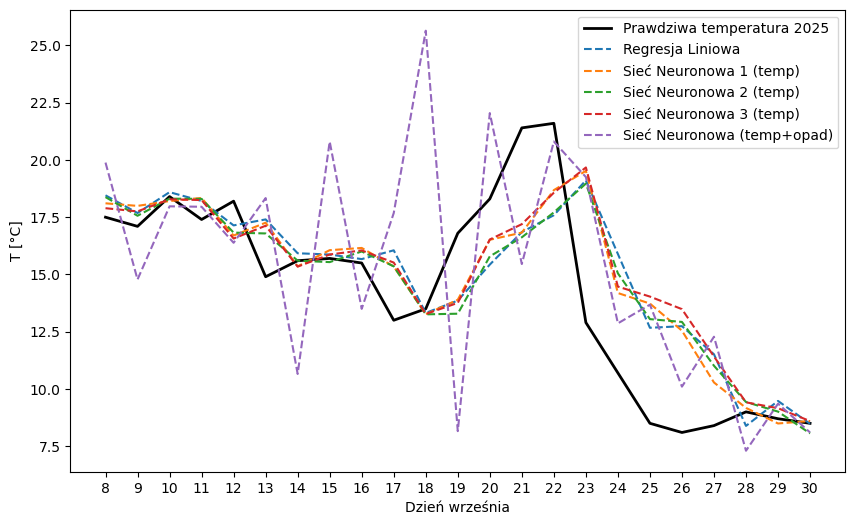

In [80]:
#Wykres dopasowania modeli na zbiorze testowym
dni = range(8, 31) #zaczynam od 8 września

plt.figure(figsize=(10, 6))
plt.plot(dni, y_test_t.numpy(), label="Prawdziwa temperatura 2025", color='black', linewidth=2)
plt.plot(dni, pred_reg.numpy(), label="Regresja Liniowa", linestyle='dashed')
plt.plot(dni, pred_nn.numpy(), label="Sieć Neuronowa 1 (temp)", linestyle='dashed')
plt.plot(dni, pred_nn_2.numpy(), label="Sieć Neuronowa 2 (temp)", linestyle='dashed')
plt.plot(dni, pred_nn_3.numpy(), label="Sieć Neuronowa 3 (temp)", linestyle='dashed')
plt.plot(dni, pred_TemOpa.numpy(), label="Sieć Neuronowa (temp+opad)", linestyle='dashed')

plt.xlabel('Dzień września')
plt.ylabel('T [°C]')
plt.xticks(dni)
plt.legend()
plt.show()

In [95]:
#Prognoza 10 dni w przyszłości za pomoca drugiego modelu sieci neuronowych (uzyskał najlepsze wyniki)
# Początek -> pierwsze 7 dni września 2025
okno = X_test_t[0].clone() 
przyszle_pred = []
dni_w_przyszlosc = 10 

with torch.no_grad():
    for d in range(dni_w_przyszlosc):
        pred = model_nn_2(okno.unsqueeze(0)) 
        przyszle_pred.append(pred.item())

        okno = torch.cat((okno[1:], pred.squeeze(0)))

prawdziwe_wartosci = y_test_t[:dni_w_przyszlosc].numpy().flatten()
dni_prognozy = range(8, 8 + dni_w_przyszlosc)

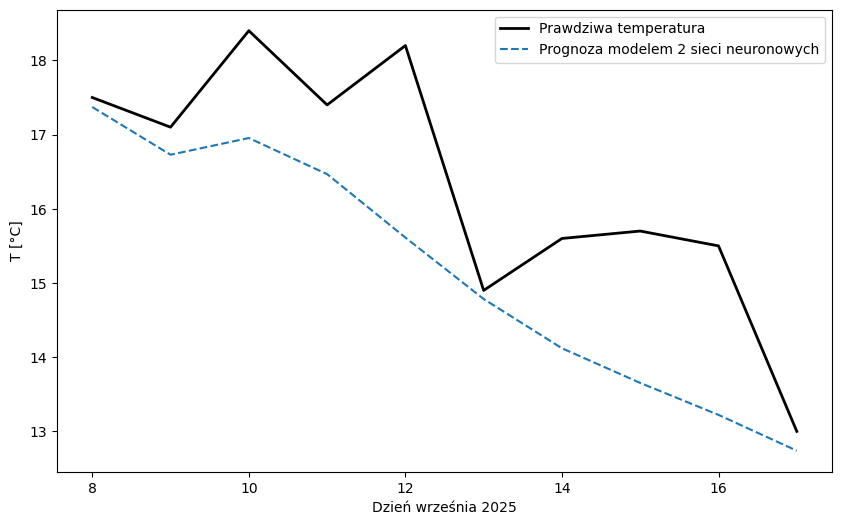

In [97]:
#Wizualizacja prognozy 10 dni w przyszłośc w zestawieniu z prawdziwymi temperaturami
plt.figure(figsize=(10, 6))
plt.plot(dni_prognozy, prawdziwe_wartosci, color='black',  linewidth=2, label='Prawdziwa temperatura')
plt.plot(dni_prognozy, przyszle_pred, linestyle='dashed', label='Prognoza modelem 2 sieci neuronowych')

plt.xlabel('Dzień września 2025')
plt.ylabel('T [°C]')
plt.legend()
plt.show()